# kNN and SVM – CICIDS2017

This notebook trains and compares k-Nearest Neighbors (kNN) and Support Vector Machine (SVM) models for the CICIDS2017 classification task.

It uses a consistent 60/20/20 train/validation/test split with `RANDOM_STATE = 42`. The loader automatically detects the target column, so it works even if the CSV uses a target column name other than `Label`.


## 1. Imports and settings


In [3]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    ConfusionMatrixDisplay,
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Keep the same split logic as the shared project file.
RANDOM_STATE = 42
TRAIN_SIZE = 0.6

print("Random state:", RANDOM_STATE)


Random state: 42


## 2. Load the data with a shared 60/20/20 split

The CSV file is expected to be in the same folder as this notebook. If your file is somewhere else, update `CSV_PATH`.

The target column is detected automatically. The function first looks for common names such as `Label`, `label`, `Class`, or `Attack`, and if none are found it uses the last column.


In [6]:
CSV_PATH = Path("cicids2017_cleaned.csv")
MAX_ROWS = 100_000


def load_and_split_data_robust(csv_path, max_rows=100000, shuffle=True):
    print(f"Loading data from {csv_path}...")
    
    df = pd.read_csv(csv_path, nrows=max_rows if shuffle else None)

    if shuffle:
        df = df.sample(
            n=min(max_rows, len(df)),
            random_state=RANDOM_STATE
        ).reset_index(drop=True)

    print(f"Loaded {len(df)} rows")
    print("Columns:")
    print(df.columns.tolist())

    # Clean column names
    df.columns = df.columns.str.strip()

    # Detect target column automatically
    possible_targets = [
        "Label",
        "label",
        "Class",
        "class",
        "Attack",
        "attack",
        "Attack Type",
        "attack_type",
        "target",
        "Target"
    ]

    target_col = next(
        (col for col in possible_targets if col in df.columns),
        df.columns[-1]
    )

    print(f"\nUsing target column: {target_col}")

    # Split features and labels
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # Convert categorical columns if needed
    X = pd.get_dummies(X, drop_first=False)

    # Handle NaN / infinite values
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(0)

    print(f"Features shape: {X.shape}")
    print("Target distribution:")
    print(y.value_counts())

    # First split
    stratify_y = y if y.value_counts().min() >= 2 else None

    X_train, X_temp, y_train, y_temp = train_test_split(
        X,
        y,
        train_size=TRAIN_SIZE,
        random_state=RANDOM_STATE,
        stratify=stratify_y
    )

    # Second split
    stratify_temp = y_temp if y_temp.value_counts().min() >= 2 else None

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        train_size=0.5,
        random_state=RANDOM_STATE,
        stratify=stratify_temp
    )

    print("\nDataset splits:")
    print(f"Train: {len(X_train)} ({100 * len(X_train) / len(df):.1f}%)")
    print(f"Validation: {len(X_val)} ({100 * len(X_val) / len(df):.1f}%)")
    print(f"Test: {len(X_test)} ({100 * len(X_test) / len(df):.1f}%)")

    return X_train, X_val, X_test, y_train, y_val, y_test


# Load dataset
X_train, X_val, X_test, y_train, y_val, y_test = load_and_split_data_robust(
    CSV_PATH,
    max_rows=MAX_ROWS,
    shuffle=True
)

print("\nFinal split shapes:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Loading data from cicids2017_cleaned.csv...
Loaded 100000 rows
Columns:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'Average Packet Size', 'Subflow Fwd Bytes', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward',

## 3. Check labels and missing values


In [7]:
display(y_train.value_counts())

print("Missing values in train:", X_train.isna().sum().sum())
print("Infinite values in train:", np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum())

# Replace possible infinite and NaN values as a safety measure.
X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
X_val = X_val.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

Attack Type
Normal Traffic    50995
Port Scanning      9005
Name: count, dtype: int64

Missing values in train: 0
Infinite values in train: 0


## 4. Helper functions for evaluation


In [8]:
results = []

def evaluate_model(name, model, X_tr, y_tr, X_va, y_va):
    start = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start

    pred = model.predict(X_va)
    acc = accuracy_score(y_va, pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_va, pred, average="weighted", zero_division=0
    )

    row = {
        "model": name,
        "accuracy": acc,
        "precision_weighted": precision,
        "recall_weighted": recall,
        "f1_weighted": f1,
        "train_time_seconds": train_time,
    }
    results.append(row)

    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 weighted: {f1:.4f}")
    print(f"Training time: {train_time:.1f}s")
    print()
    print(classification_report(y_va, pred, zero_division=0))

    return model, pred

def plot_confusion(y_true, y_pred, title):
    fig, ax = plt.subplots(figsize=(10, 8))
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        xticks_rotation=90,
        ax=ax,
        colorbar=False
    )
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

## 5. Baseline models


=== kNN baseline: StandardScaler, k=5, distance ===
Accuracy: 0.9999
F1 weighted: 0.9999
Training time: 0.1s

                precision    recall  f1-score   support

Normal Traffic       1.00      1.00      1.00     16999
 Port Scanning       1.00      1.00      1.00      3001

      accuracy                           1.00     20000
     macro avg       1.00      1.00      1.00     20000
  weighted avg       1.00      1.00      1.00     20000



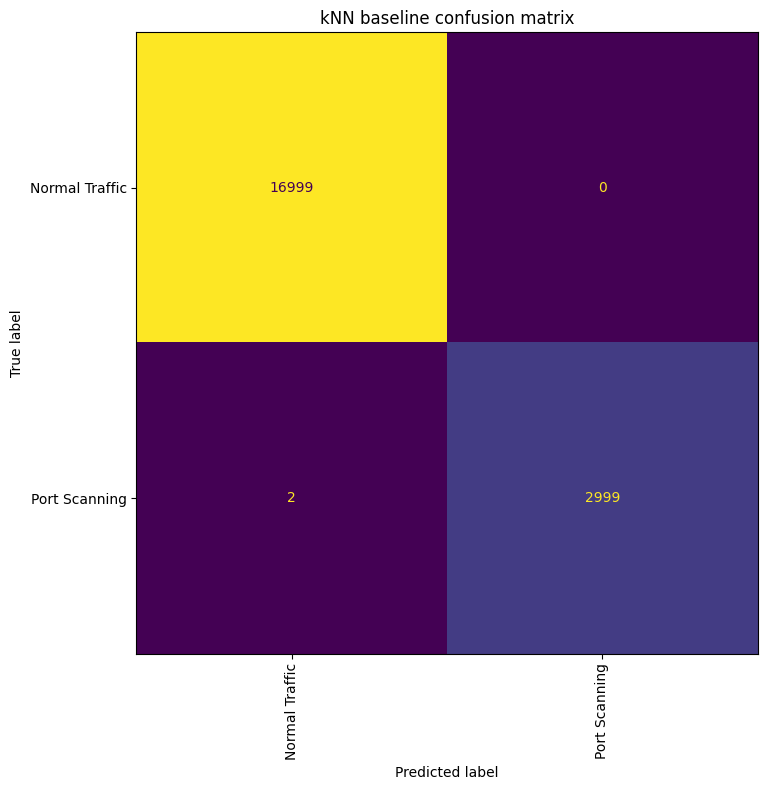

In [10]:
knn_baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5, weights="distance"))
])

knn_baseline, knn_pred = evaluate_model(
    "kNN baseline: StandardScaler, k=5, distance",
    knn_baseline,
    X_train, y_train,
    X_val, y_val
)

plot_confusion(y_val, knn_pred, "kNN baseline confusion matrix")

=== Linear SVM baseline: StandardScaler, C=1.0, balanced ===
Accuracy: 0.9989
F1 weighted: 0.9989
Training time: 2.9s

                precision    recall  f1-score   support

Normal Traffic       1.00      1.00      1.00     16999
 Port Scanning       0.99      1.00      1.00      3001

      accuracy                           1.00     20000
     macro avg       1.00      1.00      1.00     20000
  weighted avg       1.00      1.00      1.00     20000



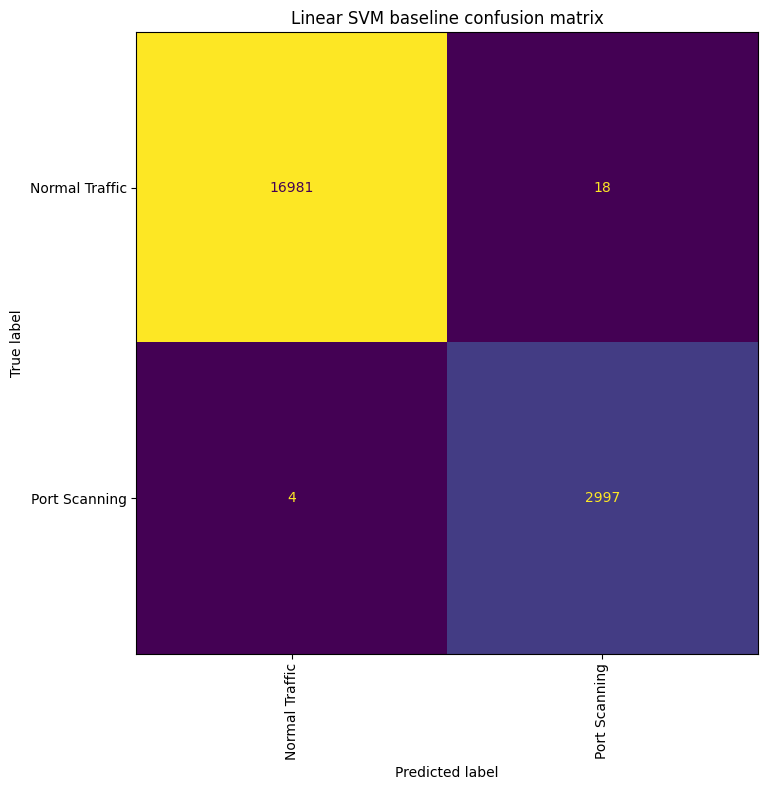

In [11]:
svm_linear_baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE, max_iter=5000))
])

svm_linear_baseline, svm_linear_pred = evaluate_model(
    "Linear SVM baseline: StandardScaler, C=1.0, balanced",
    svm_linear_baseline,
    X_train, y_train,
    X_val, y_val
)

plot_confusion(y_val, svm_linear_pred, "Linear SVM baseline confusion matrix")

## 6. kNN: scaler, SMOTE and PCA comparison


In [12]:
knn_experiments = [
    {
        "name": "kNN StandardScaler",
        "pipeline": ImbPipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=5, weights="distance"))
        ])
    },
    {
        "name": "kNN MinMaxScaler",
        "pipeline": ImbPipeline([
            ("scaler", MinMaxScaler()),
            ("model", KNeighborsClassifier(n_neighbors=5, weights="distance"))
        ])
    },
    {
        "name": "kNN StandardScaler + SMOTE",
        "pipeline": ImbPipeline([
            ("scaler", StandardScaler()),
            ("smote", SMOTE(random_state=RANDOM_STATE)),
            ("model", KNeighborsClassifier(n_neighbors=5, weights="distance"))
        ])
    },
    {
        "name": "kNN StandardScaler + PCA(0.95)",
        "pipeline": ImbPipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
            ("model", KNeighborsClassifier(n_neighbors=5, weights="distance"))
        ])
    },
]

for exp in knn_experiments:
    evaluate_model(exp["name"], exp["pipeline"], X_train, y_train, X_val, y_val)

pd.DataFrame(results).sort_values("f1_weighted", ascending=False)

=== kNN StandardScaler ===
Accuracy: 0.9999
F1 weighted: 0.9999
Training time: 0.1s

                precision    recall  f1-score   support

Normal Traffic       1.00      1.00      1.00     16999
 Port Scanning       1.00      1.00      1.00      3001

      accuracy                           1.00     20000
     macro avg       1.00      1.00      1.00     20000
  weighted avg       1.00      1.00      1.00     20000

=== kNN MinMaxScaler ===
Accuracy: 0.9999
F1 weighted: 0.9998
Training time: 0.1s

                precision    recall  f1-score   support

Normal Traffic       1.00      1.00      1.00     16999
 Port Scanning       1.00      1.00      1.00      3001

      accuracy                           1.00     20000
     macro avg       1.00      1.00      1.00     20000
  weighted avg       1.00      1.00      1.00     20000

=== kNN StandardScaler + SMOTE ===
Accuracy: 0.9999
F1 weighted: 0.9999
Training time: 0.3s

                precision    recall  f1-score   support

Norm

,model,accuracy,precision_weighted,recall_weighted,f1_weighted,train_time_seconds
0,"kNN baseline: StandardScaler, k=5, distance",0.99990,0.999900,0.99990,0.999900,0.080379
1,"kNN baseline: StandardScaler, k=5, distance",0.99990,0.999900,0.99990,0.999900,0.084305
3,kNN StandardScaler,0.99990,0.999900,0.99990,0.999900,0.076524
6,kNN StandardScaler + PCA(0.95),0.99990,0.999900,0.99990,0.999900,0.100971
5,kNN StandardScaler + SMOTE,0.99990,0.999900,0.99990,0.999900,0.299540
4,kNN MinMaxScaler,0.99985,0.999850,0.99985,0.999850,0.062777
2,"Linear SVM baseline: StandardScaler, C=1.0, ba...",0.99890,0.998904,0.99890,0.998901,2.864317


## 7. SVM: scaler, SMOTE and PCA comparison


In [13]:
svm_experiments = [
    {
        "name": "Linear SVM StandardScaler",
        "pipeline": ImbPipeline([
            ("scaler", StandardScaler()),
            ("model", LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE, max_iter=5000))
        ])
    },
    {
        "name": "Linear SVM MinMaxScaler",
        "pipeline": ImbPipeline([
            ("scaler", MinMaxScaler()),
            ("model", LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE, max_iter=5000))
        ])
    },
    {
        "name": "Linear SVM StandardScaler + SMOTE",
        "pipeline": ImbPipeline([
            ("scaler", StandardScaler()),
            ("smote", SMOTE(random_state=RANDOM_STATE)),
            ("model", LinearSVC(C=1.0, random_state=RANDOM_STATE, max_iter=5000))
        ])
    },
    {
        "name": "Linear SVM StandardScaler + PCA(0.95)",
        "pipeline": ImbPipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
            ("model", LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE, max_iter=5000))
        ])
    },
]

for exp in svm_experiments:
    evaluate_model(exp["name"], exp["pipeline"], X_train, y_train, X_val, y_val)

pd.DataFrame(results).sort_values("f1_weighted", ascending=False)

=== Linear SVM StandardScaler ===
Accuracy: 0.9989
F1 weighted: 0.9989
Training time: 2.8s

                precision    recall  f1-score   support

Normal Traffic       1.00      1.00      1.00     16999
 Port Scanning       0.99      1.00      1.00      3001

      accuracy                           1.00     20000
     macro avg       1.00      1.00      1.00     20000
  weighted avg       1.00      1.00      1.00     20000

=== Linear SVM MinMaxScaler ===
Accuracy: 0.9920
F1 weighted: 0.9921
Training time: 0.3s

                precision    recall  f1-score   support

Normal Traffic       1.00      0.99      1.00     16999
 Port Scanning       0.95      1.00      0.97      3001

      accuracy                           0.99     20000
     macro avg       0.98      0.99      0.98     20000
  weighted avg       0.99      0.99      0.99     20000

=== Linear SVM StandardScaler + SMOTE ===
Accuracy: 0.9990
F1 weighted: 0.9990
Training time: 7.1s

                precision    recall  f1-

,model,accuracy,precision_weighted,recall_weighted,f1_weighted,train_time_seconds
0,"kNN baseline: StandardScaler, k=5, distance",0.99990,0.999900,0.99990,0.999900,0.080379
1,"kNN baseline: StandardScaler, k=5, distance",0.99990,0.999900,0.99990,0.999900,0.084305
3,kNN StandardScaler,0.99990,0.999900,0.99990,0.999900,0.076524
6,kNN StandardScaler + PCA(0.95),0.99990,0.999900,0.99990,0.999900,0.100971
5,kNN StandardScaler + SMOTE,0.99990,0.999900,0.99990,0.999900,0.299540
4,kNN MinMaxScaler,0.99985,0.999850,0.99985,0.999850,0.062777
10,Linear SVM StandardScaler + PCA(0.95),0.99900,0.999003,0.99900,0.999001,1.097437
9,Linear SVM StandardScaler + SMOTE,0.99895,0.998954,0.99895,0.998951,7.075881
2,"Linear SVM baseline: StandardScaler, C=1.0, ba...",0.99890,0.998904,0.99890,0.998901,2.864317
7,Linear SVM StandardScaler,0.99890,0.998904,0.99890,0.998901,2.786220


## 8. GridSearchCV for kNN


Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best params: {'model__metric': 'euclidean', 'model__n_neighbors': 5, 'model__weights': 'distance', 'scaler': MinMaxScaler()}
Best CV f1_weighted: 0.9998332944410997
                precision    recall  f1-score   support

Normal Traffic       1.00      1.00      1.00     16999
 Port Scanning       1.00      1.00      1.00      3001

      accuracy                           1.00     20000
     macro avg       1.00      1.00      1.00     20000
  weighted avg       1.00      1.00      1.00     20000



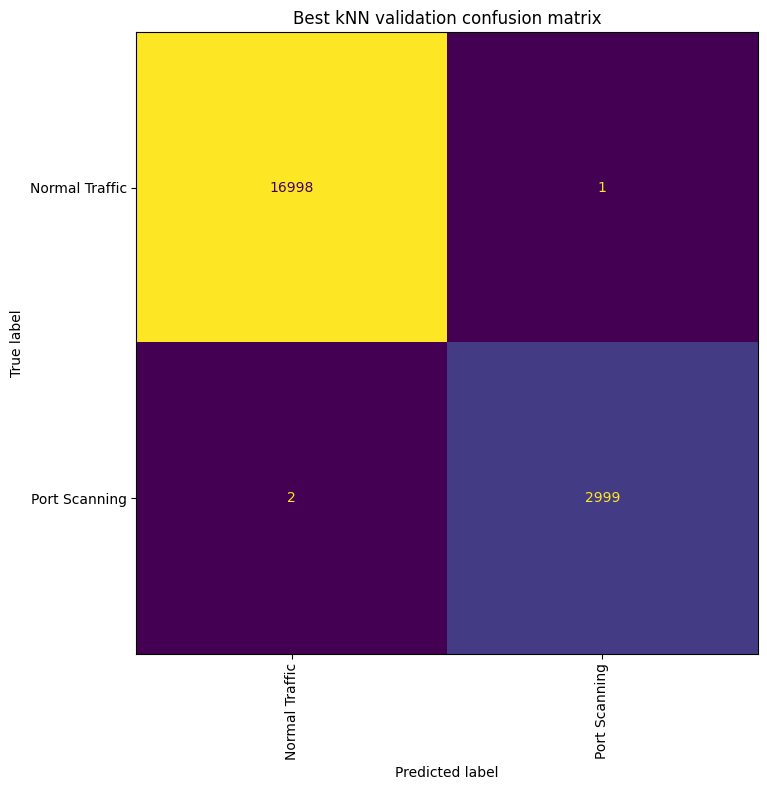

In [15]:
knn_grid = ImbPipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

knn_param_grid = {
    "scaler": [StandardScaler(), MinMaxScaler()],
    "model__n_neighbors": [3, 5, 7, 11],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"],
}

knn_search = GridSearchCV(
    knn_grid,
    param_grid=knn_param_grid,
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1,
    verbose=2
)

knn_search.fit(X_train, y_train)

print("Best params:", knn_search.best_params_)
print("Best CV f1_weighted:", knn_search.best_score_)

knn_best = knn_search.best_estimator_
knn_best_pred = knn_best.predict(X_val)

print(classification_report(y_val, knn_best_pred, zero_division=0))
plot_confusion(y_val, knn_best_pred, "Best kNN validation confusion matrix")

results.append({
    "model": "kNN GridSearch best",
    "accuracy": accuracy_score(y_val, knn_best_pred),
    "precision_weighted": precision_recall_fscore_support(y_val, knn_best_pred, average="weighted", zero_division=0)[0],
    "recall_weighted": precision_recall_fscore_support(y_val, knn_best_pred, average="weighted", zero_division=0)[1],
    "f1_weighted": precision_recall_fscore_support(y_val, knn_best_pred, average="weighted", zero_division=0)[2],
    "train_time_seconds": np.nan,
})

## 9. GridSearchCV for SVM


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'model__C': 10, 'model__class_weight': None, 'scaler': StandardScaler()}
Best CV f1_weighted: 0.9992166426468266
                precision    recall  f1-score   support

Normal Traffic       1.00      1.00      1.00     16999
 Port Scanning       1.00      1.00      1.00      3001

      accuracy                           1.00     20000
     macro avg       1.00      1.00      1.00     20000
  weighted avg       1.00      1.00      1.00     20000



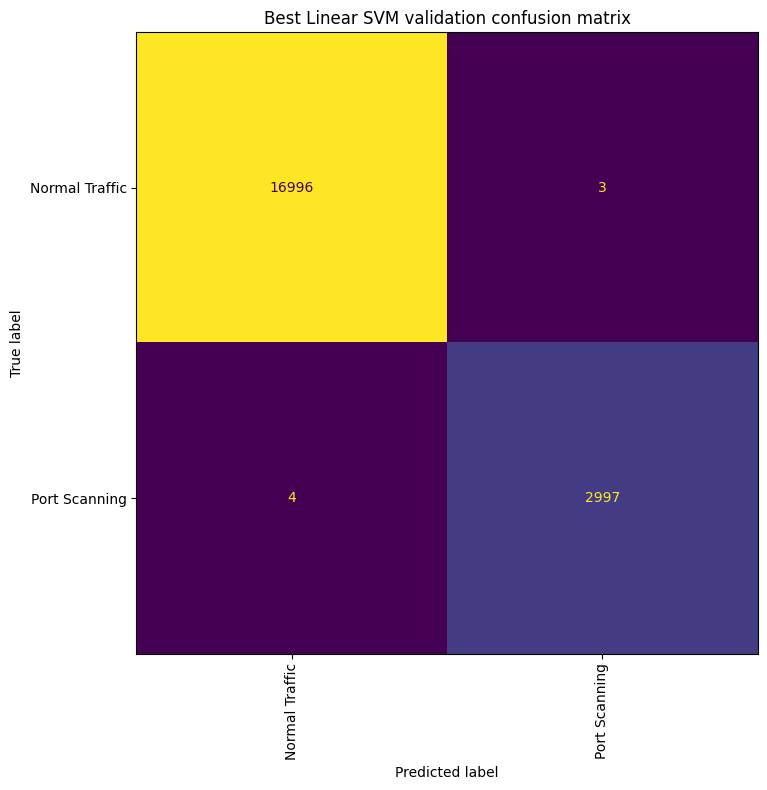

In [16]:
svm_grid = ImbPipeline([
    ("scaler", StandardScaler()),
    ("model", LinearSVC(random_state=RANDOM_STATE, max_iter=5000))
])

svm_param_grid = {
    "scaler": [StandardScaler(), MinMaxScaler()],
    "model__C": [0.1, 1, 10],
    "model__class_weight": [None, "balanced"],
}

svm_search = GridSearchCV(
    svm_grid,
    param_grid=svm_param_grid,
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1,
    verbose=2
)

svm_search.fit(X_train, y_train)

print("Best params:", svm_search.best_params_)
print("Best CV f1_weighted:", svm_search.best_score_)

svm_best = svm_search.best_estimator_
svm_best_pred = svm_best.predict(X_val)

print(classification_report(y_val, svm_best_pred, zero_division=0))
plot_confusion(y_val, svm_best_pred, "Best Linear SVM validation confusion matrix")

results.append({
    "model": "Linear SVM GridSearch best",
    "accuracy": accuracy_score(y_val, svm_best_pred),
    "precision_weighted": precision_recall_fscore_support(y_val, svm_best_pred, average="weighted", zero_division=0)[0],
    "recall_weighted": precision_recall_fscore_support(y_val, svm_best_pred, average="weighted", zero_division=0)[1],
    "f1_weighted": precision_recall_fscore_support(y_val, svm_best_pred, average="weighted", zero_division=0)[2],
    "train_time_seconds": np.nan,
})

## 10. Optional: RBF SVM on a smaller sample


=== RBF SVM sample baseline ===
Accuracy: 0.9935
F1 weighted: 0.9936
Training time: 0.3s

                precision    recall  f1-score   support

Normal Traffic       1.00      0.99      1.00     16999
 Port Scanning       0.96      1.00      0.98      3001

      accuracy                           0.99     20000
     macro avg       0.98      1.00      0.99     20000
  weighted avg       0.99      0.99      0.99     20000



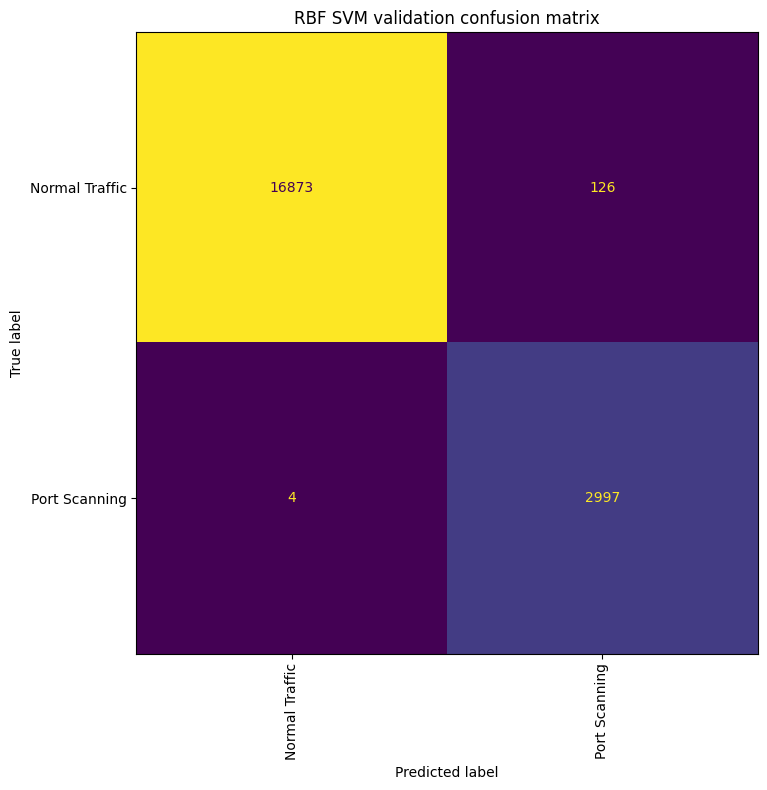

In [17]:
# Take a small subset for the RBF SVM experiment
RBF_SAMPLE_SIZE = 20_000

if len(X_train) > RBF_SAMPLE_SIZE:
    X_train_rbf = X_train.sample(RBF_SAMPLE_SIZE, random_state=RANDOM_STATE)
    y_train_rbf = y_train.loc[X_train_rbf.index]
else:
    X_train_rbf = X_train
    y_train_rbf = y_train

rbf_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced", random_state=RANDOM_STATE))
])

rbf_svm, rbf_pred = evaluate_model(
    "RBF SVM sample baseline",
    rbf_svm,
    X_train_rbf, y_train_rbf,
    X_val, y_val
)

plot_confusion(y_val, rbf_pred, "RBF SVM validation confusion matrix")

## 11. Compare the results


In [18]:
results_df = pd.DataFrame(results).sort_values("f1_weighted", ascending=False)
display(results_df)

results_df.to_csv("knn_svm_results.csv", index=False)
print("Saved: knn_svm_results.csv")

,model,accuracy,precision_weighted,recall_weighted,f1_weighted,train_time_seconds
0,"kNN baseline: StandardScaler, k=5, distance",0.99990,0.999900,0.99990,0.999900,0.080379
1,"kNN baseline: StandardScaler, k=5, distance",0.99990,0.999900,0.99990,0.999900,0.084305
3,kNN StandardScaler,0.99990,0.999900,0.99990,0.999900,0.076524
5,kNN StandardScaler + SMOTE,0.99990,0.999900,0.99990,0.999900,0.299540
6,kNN StandardScaler + PCA(0.95),0.99990,0.999900,0.99990,0.999900,0.100971
4,kNN MinMaxScaler,0.99985,0.999850,0.99985,0.999850,0.062777
11,kNN GridSearch best,0.99985,0.999850,0.99985,0.999850,NaN
12,Linear SVM GridSearch best,0.99965,0.999650,0.99965,0.999650,NaN
10,Linear SVM StandardScaler + PCA(0.95),0.99900,0.999003,0.99900,0.999001,1.097437
9,Linear SVM StandardScaler + SMOTE,0.99895,0.998954,0.99895,0.998951,7.075881


Saved: knn_svm_results.csv


## 12. Test the best model on the test data


Best model based on validation results: kNN baseline: StandardScaler, k=5, distance
FINAL MODEL: Linear SVM GridSearch best
Test accuracy: 0.99945
                precision    recall  f1-score   support

Normal Traffic       1.00      1.00      1.00     16998
 Port Scanning       1.00      1.00      1.00      3002

      accuracy                           1.00     20000
     macro avg       1.00      1.00      1.00     20000
  weighted avg       1.00      1.00      1.00     20000



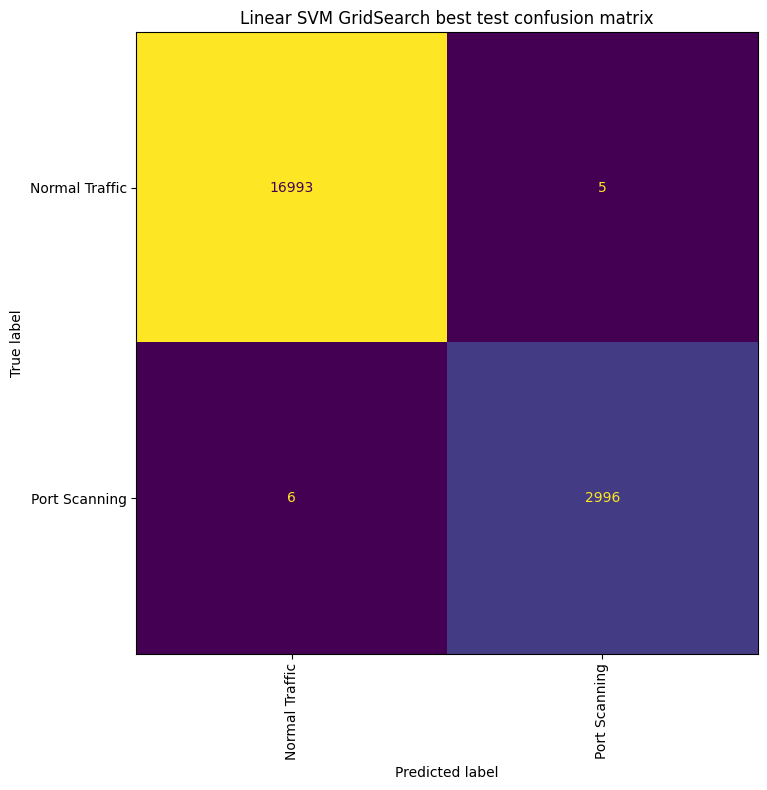

In [19]:
candidate_models = {
    "kNN GridSearch best": knn_best,
    "Linear SVM GridSearch best": svm_best,
}

best_name = results_df.iloc[0]["model"]
print("Best model based on validation results:", best_name)

# If the best model was something other than a GridSearch model, choose manually:
# final_model = knn_best
# final_model_name = "kNN GridSearch best"

if best_name in candidate_models:
    final_model = candidate_models[best_name]
    final_model_name = best_name
else:
    final_model = svm_best
    final_model_name = "Linear SVM GridSearch best"

test_pred = final_model.predict(X_test)

print("FINAL MODEL:", final_model_name)
print("Test accuracy:", accuracy_score(y_test, test_pred))
print(classification_report(y_test, test_pred, zero_division=0))
plot_confusion(y_test, test_pred, f"{final_model_name} test confusion matrix")

## 13. Short summary for the report

Use this section to write the final short interpretation after running the notebook.

- Best kNN result:
  - Validation accuracy:
  - Validation weighted F1:
  - Best parameters:

- Best SVM result:
  - Validation accuracy:
  - Validation weighted F1:
  - Best parameters:

- Final selected model:
  - Test accuracy:
  - Test weighted F1:

- Notes:
  - Was SMOTE useful?
  - Which scaler worked better?
  - Did PCA help?
  - Which model was better, kNN or SVM?
